# **Heart Disease Prediction with Random Forest**

## **Project Summary**

This project aimed to develop a machine learning model for predicting heart disease.

**Key Objectives & Accomplishments:**

*   **Exploratory Data Analysis (EDA):** Visualizations were created to understand the distribution, relationships, and potential predictive power of various features such as Age, Sex, ChestPainType, Cholesterol, MaxHR, and ST_Slope in relation to heart disease.

*   **Random Forest Implementation:** A Random Forest Classifier was chosen as the primary modeling technique due to its strong performance in classification tasks and its ability to handle complex datasets. The model was trained and evaluated on the heart disease prediction task.

*   **Hyperparameter Tuning with GridSearchCV:** To optimize the Random Forest model's performance, GridSearchCV was employed. This systematic approach helped in finding the best combination of hyperparameters, such as `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`, leading to an improved accuracy of **0.8859** with the best parameters.

*   **Model Evaluation and Misclassification Analysis:** The model's performance was rigorously assessed using standard metrics like accuracy, precision, recall, F1-score, and confusion matrices. Critical analysis of misclassified samples (False Positives and False Negatives) was performed to understand the model's limitations and identify areas for potential future improvement.

***This project served to reinforce understanding and practical application of Random Forest models, hyperparameter optimization, and the critical role of data visualization and exploratory analysis in building effective machine learning solutions.***

# **Attribute Information**

* Age: age of the patient [years]

* Sex: sex of the patient [M: Male, F: Female]

* ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

* RestingBP: resting blood pressure [mm Hg]

* Cholesterol: serum cholesterol [mm/dl]

* FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

* RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

* MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

* ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

* Oldpeak: oldpeak = ST [Numeric value measured in depression]

* ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

* HeartDisease: output class [1: heart disease, 0: Normal]

In [52]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [53]:
import os
import pandas as pd
import plotly
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [54]:
data = os.listdir(path)
csv = 'heart.csv'
df = pd.read_csv(os.path.join(path, csv))

In [55]:
pd.options.display.max_columns = None
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [56]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [58]:
# Age vs. HeartDisease
fig_age = px.box(df, x='HeartDisease', y='Age',
                 title='Age Distribution by Heart Disease Status',
                 labels={'HeartDisease': 'Heart Disease (0: No, 1: Yes)', 'Age': 'Age'})
fig_age.show()

In [59]:
# Sex vs. HeartDisease
fig_sex = px.histogram(df, x='Sex', color='HeartDisease', barmode='group',
                       title='Sex Distribution by Heart Disease Status',
                       labels={'HeartDisease': 'Heart Disease (0: No, 1: Yes)'})
fig_sex.show()

In [ ]:
# ST_Slope vs. HeartDisease
fig_st_slope = px.histogram(df, x='ST_Slope', color='HeartDisease', barmode='group',
                            title='ST_Slope Distribution by Heart Disease Status',
                            labels={'HeartDisease': 'Heart Disease (0: No, 1: Yes)'})
fig_st_slope.show()

In [ ]:
# ChestPainType vs. HeartDisease
fig_chest_pain = px.histogram(df, x='ChestPainType', color='HeartDisease', barmode='group',
                              title='ChestPainType Distribution by Heart Disease Status',
                              labels={'HeartDisease': 'Heart Disease (0: No, 1: Yes)'})
fig_chest_pain.show()

In [ ]:
# Cholesterol vs. HeartDisease
fig_cholesterol = px.box(df, x='HeartDisease', y='Cholesterol',
                         title='Cholesterol Distribution by Heart Disease Status',
                         labels={'HeartDisease': 'Heart Disease (0: No, 1: Yes)', 'Cholesterol': 'Cholesterol (mm/dl)'})
fig_cholesterol.show()

In [ ]:
# MaxHR vs. HeartDisease
fig_maxhr = px.box(df, x='HeartDisease', y='MaxHR',
                   title='Maximum Heart Rate (MaxHR) Distribution by Heart Disease Status',
                   labels={'HeartDisease': 'Heart Disease (0: No, 1: Yes)', 'MaxHR': 'MaxHR'})
fig_maxhr.show()

# **Random Forest Prediction Model**

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [61]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train :", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train :", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of X_train : (734, 15)
Shape of X_test : (184, 15)
Shape of y_train : (734,)
Shape of y_test : (184,)


Accuracy : 0.8750

Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184


Confusion Matrix :


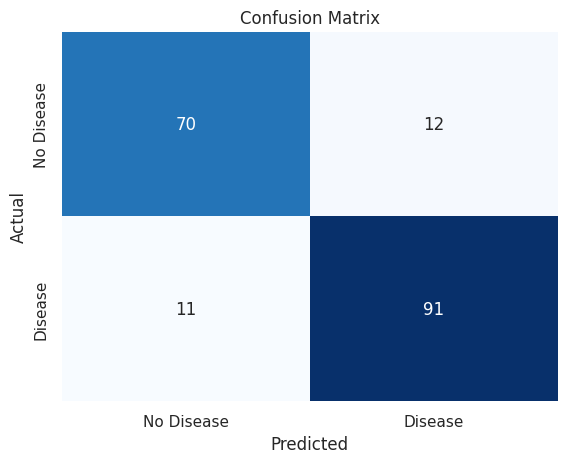

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report :")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix :")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **GridSearchCv**

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation accuracy : 0.8705246482154505
Accuracy : 0.8859

Classification Report :
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


Confusion Matrix :


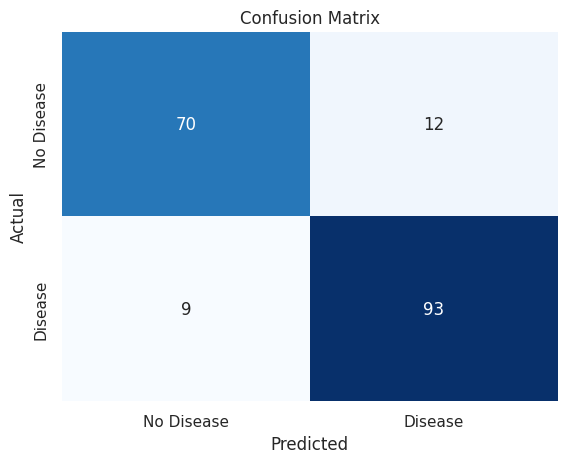

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2,
                           scoring='accuracy')

grid_search.fit(X_train, y_train)

print("\nBest parameters :", grid_search.best_params_)
print("Best cross-validation accuracy :", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")

print("\nClassification Report :")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix :")
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [64]:
misclassified_df = df.loc[misclassified_indices].copy()
misclassified_df['Actual_HeartDisease'] = y_test.loc[misclassified_indices]
predicted_for_misclassified = pd.Series(y_pred_best, index=X_test.index).loc[misclassified_indices]
misclassified_df['Predicted_HeartDisease'] = predicted_for_misclassified

false_negatives = misclassified_df[misclassified_df['Actual_HeartDisease'] == 1]
false_positives = misclassified_df[misclassified_df['Actual_HeartDisease'] == 0]

display(misclassified_df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Actual_HeartDisease,Predicted_HeartDisease
763,58,M,NAP,132,224,0,LVH,173,N,3.2,Up,1,1,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1,0
840,41,M,ATA,135,203,0,Normal,132,N,0.0,Flat,0,0,1
21,44,M,ATA,120,184,0,Normal,142,N,1.0,Flat,0,0,1
314,53,M,ASY,80,0,0,Normal,141,Y,2.0,Down,0,0,1


In [66]:
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for feature in categorical_features:
    fig = px.histogram(misclassified_df, x=feature, color='Actual_HeartDisease', barmode='group',
                       title=f'Distribution of {feature} in Misclassified Samples',
                       labels={'Actual_HeartDisease': 'Actual Heart Disease (0: No, 1: Yes)'})
    fig.show()

In [67]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for feature in numerical_features:
    fig = px.box(misclassified_df, x='Actual_HeartDisease', y=feature,
                 title=f'Distribution of {feature} in Misclassified Samples',
                 labels={'Actual_HeartDisease': 'Actual Heart Disease (0: No, 1: Yes)'})
    fig.show()